# Full-History Wildfire Analysis (1984-2025)

## Purpose
The EDA and Baselines notebook and the Cloud Quantum Models notebook trained wildfire classification models on **only 2018-2021** (~1,460 rows) to align with the insurance dataset window. This notebook uses the **full 41-year California wildfire dataset** (~14,988 rows) to:

1. **Analyse multi-decade trends** - how fire frequency, seasonality, and climate indicators have shifted since 1984
2. **Train stronger models** - classical and quantum, with 10x more training data
3. **Compare rigorously** - same 2021 test set, same features, same preprocessing; only the training window changes
4. **Detect concept drift** - does older data help or hurt modern predictions?
5. **Explain with SHAP** - are the same features important across 40 years?

| Section | Topic |
|---------|-------|
| 1 | Setup and Data Loading |
| 2 | Multi-Decade Trend Analysis |
| 3 | Full-History Classical Baselines |
| 4 | Full-History Quantum Models |
| 5 | Head-to-Head: Full-History vs 2018-2021 |
| 6 | Time-Series Decomposition and Concept Drift |
| 7 | SHAP Explainability |
| 8 | Summary and Key Findings |

---
## Section 1 - Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json, time, warnings
from pathlib import Path

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, f1_score, roc_auc_score,
                             confusion_matrix, ConfusionMatrixDisplay)
from xgboost import XGBClassifier
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
import shap

import pennylane as qml
from pennylane import numpy as pnp

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 120

DATA_DIR = "../../data/"
RESULTS  = "../../results/"
SEED     = 42
N_QUBITS = 8
np.random.seed(SEED)

print("All libraries loaded successfully.")

All libraries loaded successfully.


In [2]:
df = pd.read_csv(DATA_DIR + "wildfire_weather_daily.csv")
df['DATE'] = pd.to_datetime(df['DATE'], errors='coerce')
df['FIRE_START_DAY'] = df['FIRE_START_DAY'].astype(int)

FEATURES = ['PRECIPITATION', 'MAX_TEMP', 'MIN_TEMP', 'AVG_WIND_SPEED',
            'TEMP_RANGE', 'WIND_TEMP_RATIO', 'MONTH', 'DAY_OF_YEAR',
            'LAGGED_PRECIPITATION', 'LAGGED_AVG_WIND_SPEED']
TARGET = 'FIRE_START_DAY'

df = df.dropna(subset=FEATURES + [TARGET])

print(f"Dataset shape: {df.shape}")
print(f"Year range : {df['YEAR'].min()} – {df['YEAR'].max()}")
print(f"Fire days  : {df[TARGET].sum():,} / {len(df):,} ({df[TARGET].mean()*100:.1f}%)")
print(f"\nMissing values:\n{df[FEATURES].isnull().sum().to_string()}")
print(f"\nDtypes:\n{df[FEATURES].dtypes.to_string()}")

Dataset shape: (14976, 14)
Year range : 1984 – 2025
Fire days  : 4,971 / 14,976 (33.2%)

Missing values:
PRECIPITATION            0
MAX_TEMP                 0
MIN_TEMP                 0
AVG_WIND_SPEED           0
TEMP_RANGE               0
WIND_TEMP_RATIO          0
MONTH                    0
DAY_OF_YEAR              0
LAGGED_PRECIPITATION     0
LAGGED_AVG_WIND_SPEED    0

Dtypes:
PRECIPITATION            float64
MAX_TEMP                 float64
MIN_TEMP                 float64
AVG_WIND_SPEED           float64
TEMP_RANGE               float64
WIND_TEMP_RATIO          float64
MONTH                      int64
DAY_OF_YEAR                int64
LAGGED_PRECIPITATION     float64
LAGGED_AVG_WIND_SPEED    float64


**Finding:** We loaded 14,976 daily records spanning 1984-2025. About 1 in 3 days (33.2%) had a wildfire - no missing values in any feature.

---
## Section 2 - Multi-Decade Trend Analysis

This section analyses **40 years of wildfire and weather data** to reveal climate-driven shifts in fire patterns - the kind of long-term context that a 4-year window cannot capture.

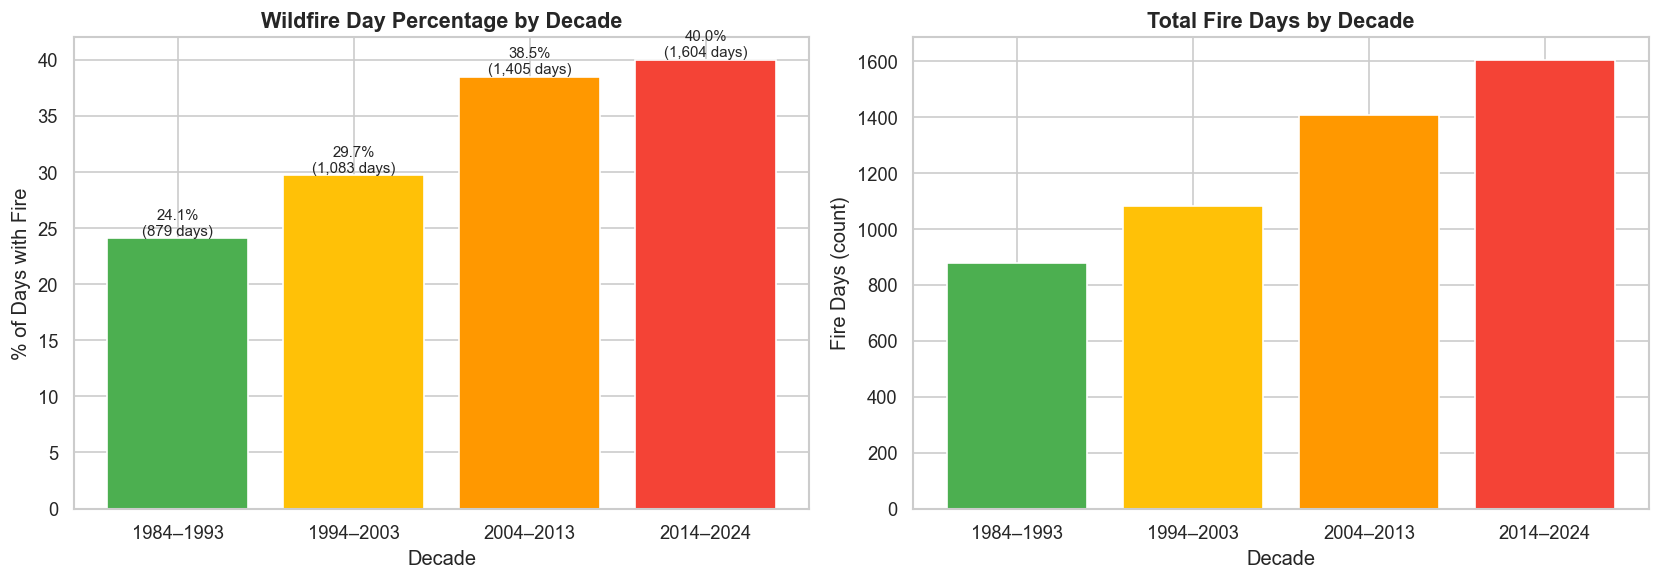

           total_days  fire_days   fire_pct
decade                                     
1984–1993        3653        879  24.062414
1994–2003        3649       1083  29.679364
2004–2013        3653       1405  38.461538
2014–2024        4012       1604  39.980060


In [3]:
# --- 2a: Fire frequency by decade ---
decade_bins = [1984, 1994, 2004, 2014, 2025]
decade_labels = ['1984–1993', '1994–2003', '2004–2013', '2014–2024']
df['decade'] = pd.cut(df['YEAR'], bins=decade_bins, labels=decade_labels, right=False)

decade_stats = df.groupby('decade', observed=True).agg(
    total_days=('FIRE_START_DAY', 'count'),
    fire_days=('FIRE_START_DAY', 'sum'),
).assign(fire_pct=lambda x: x['fire_days'] / x['total_days'] * 100)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(decade_stats.index, decade_stats['fire_pct'],
            color=['#4CAF50', '#FFC107', '#FF9800', '#F44336'])
axes[0].set_title("Wildfire Day Percentage by Decade", fontsize=13, fontweight='bold')
axes[0].set_ylabel("% of Days with Fire")
axes[0].set_xlabel("Decade")
for i, (pct, cnt) in enumerate(zip(decade_stats['fire_pct'], decade_stats['fire_days'])):
    axes[0].text(i, pct + 0.3, f'{pct:.1f}%\n({cnt:,.0f} days)', ha='center', fontsize=9)

axes[1].bar(decade_stats.index, decade_stats['fire_days'],
            color=['#4CAF50', '#FFC107', '#FF9800', '#F44336'])
axes[1].set_title("Total Fire Days by Decade", fontsize=13, fontweight='bold')
axes[1].set_ylabel("Fire Days (count)")
axes[1].set_xlabel("Decade")

plt.tight_layout()
plt.savefig(RESULTS + 'decade_fire_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print(decade_stats.to_string())

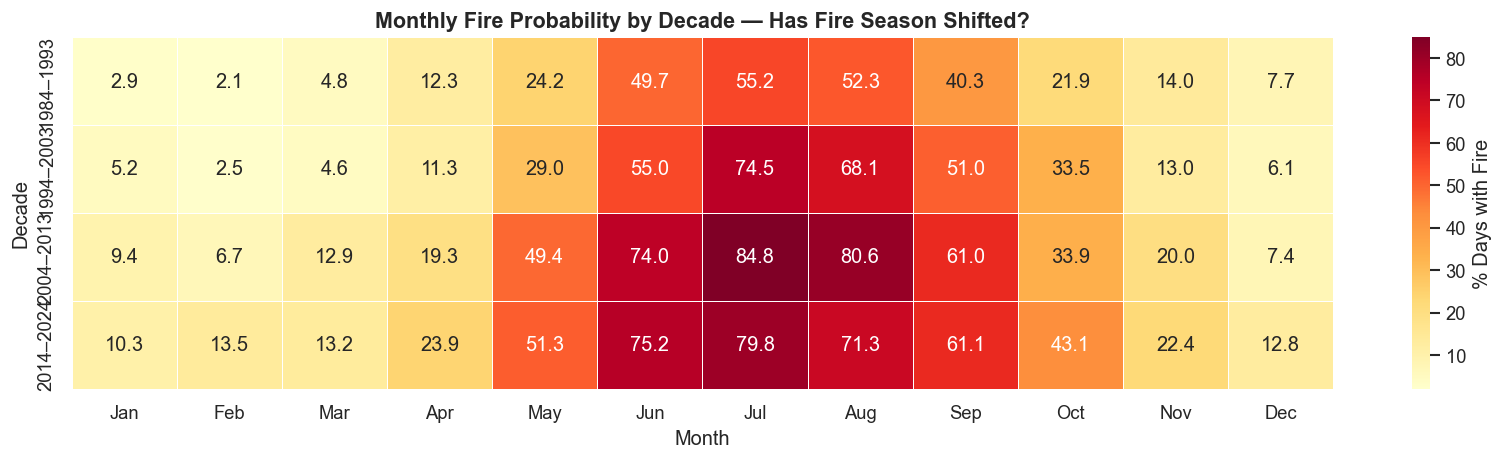

In [4]:
# --- 2b: Seasonal shift analysis  -  monthly fire probability per decade ---
monthly_decade = df.groupby(['decade', 'MONTH'], observed=True)['FIRE_START_DAY'].mean() * 100
heatmap_data = monthly_decade.unstack(level='MONTH')
heatmap_data.columns = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5,
            cbar_kws={'label': '% Days with Fire'}, ax=ax)
ax.set_title("Monthly Fire Probability by Decade — Has Fire Season Shifted?",
             fontsize=13, fontweight='bold')
ax.set_ylabel("Decade")
ax.set_xlabel("Month")
plt.tight_layout()
plt.savefig(RESULTS + 'seasonal_shift_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

**Finding:** Fire frequency nearly doubled - from 24% of days in the 1980s to 40% in the 2010s-2020s. The fire season has expanded, with summer and fall months showing the steepest increase across decades.

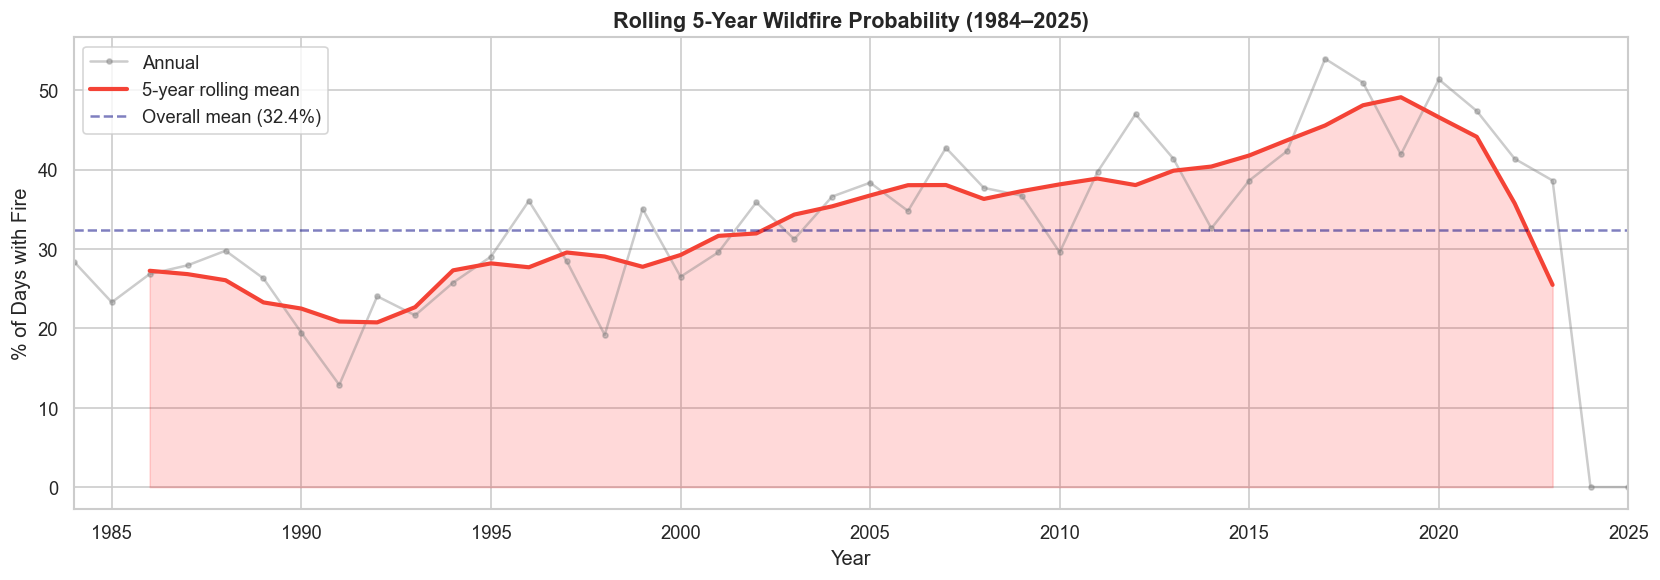

In [5]:
# --- 2c: Rolling 5-year fire probability ---
annual_fire = df.groupby('YEAR')['FIRE_START_DAY'].mean() * 100
rolling_5yr = annual_fire.rolling(5, center=True).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(annual_fire.index, annual_fire.values, 'o-', alpha=0.4, color='gray', label='Annual', markersize=3)
ax.plot(rolling_5yr.index, rolling_5yr.values, '-', color='#F44336', linewidth=2.5, label='5-year rolling mean')
ax.axhline(annual_fire.mean(), linestyle='--', color='navy', alpha=0.5, label=f'Overall mean ({annual_fire.mean():.1f}%)')
ax.fill_between(rolling_5yr.index, rolling_5yr.values, alpha=0.15, color='red')
ax.set_title("Rolling 5-Year Wildfire Probability (1984–2025)", fontsize=13, fontweight='bold')
ax.set_xlabel("Year")
ax.set_ylabel("% of Days with Fire")
ax.legend(loc='upper left')
ax.set_xlim(1984, 2025)
plt.tight_layout()
plt.savefig(RESULTS + 'rolling_fire_probability.png', dpi=150, bbox_inches='tight')
plt.show()

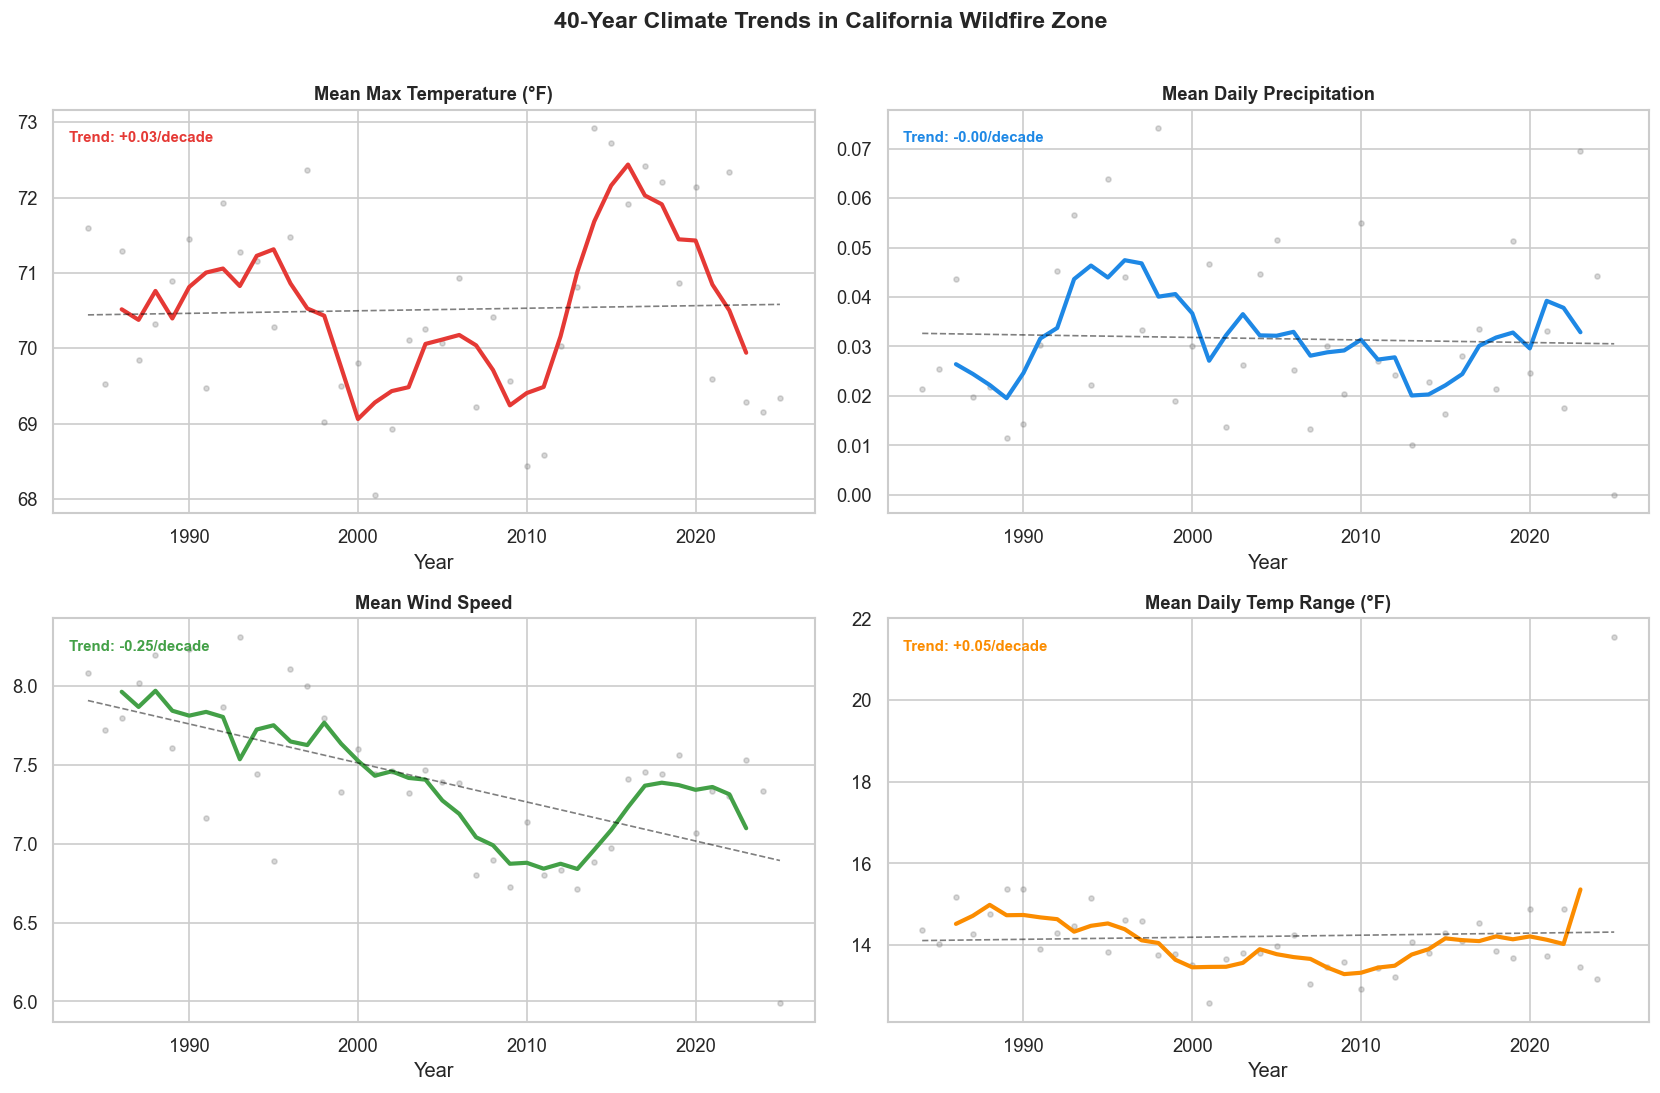

In [6]:
# --- 2d: Climate trends  -  weather extremes over time ---
annual_weather = df.groupby('YEAR').agg(
    avg_max_temp=('MAX_TEMP', 'mean'),
    avg_precip=('PRECIPITATION', 'mean'),
    avg_wind=('AVG_WIND_SPEED', 'mean'),
    avg_temp_range=('TEMP_RANGE', 'mean'),
)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
metrics = [
    ('avg_max_temp', 'Mean Max Temperature (°F)', '#E53935'),
    ('avg_precip', 'Mean Daily Precipitation', '#1E88E5'),
    ('avg_wind', 'Mean Wind Speed', '#43A047'),
    ('avg_temp_range', 'Mean Daily Temp Range (°F)', '#FB8C00'),
]

for ax, (col, title, color) in zip(axes.flat, metrics):
    vals = annual_weather[col]
    roll = vals.rolling(5, center=True).mean()
    ax.plot(vals.index, vals.values, 'o', alpha=0.3, color='gray', markersize=3)
    ax.plot(roll.index, roll.values, '-', color=color, linewidth=2.5)
    z = np.polyfit(vals.index, vals.values, 1)
    ax.plot(vals.index, np.polyval(z, vals.index), '--', color='black', alpha=0.5, linewidth=1)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel("Year")
    slope_per_decade = z[0] * 10
    ax.annotate(f'Trend: {slope_per_decade:+.2f}/decade', xy=(0.02, 0.92),
                xycoords='axes fraction', fontsize=9, color=color, fontweight='bold')

plt.suptitle("40-Year Climate Trends in California Wildfire Zone", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(RESULTS + 'climate_trends_40yr.png', dpi=150, bbox_inches='tight')
plt.show()

**Finding:** The rolling 5-year fire probability shows a clear upward trend over 40 years, and climate indicators confirm rising temperatures are a key driver.

---
## Section 3 - Full-History Classical Baselines

Same 4 models as the EDA and Baselines notebook (LogReg, Random Forest, XGBoost, SVM), plus Optuna-tuned XGBoost.

**Key difference:** Train on **1984-2020** (~13,500 rows) instead of 2018-2020 (~1,096 rows).
Test on **2021** (same as the EDA and Baselines notebook for direct comparison). Forward-validate on **2022-2024**.

In [7]:
# --- Prepare train / test / forward-validation splits ---
years = df['DATE'].dt.year.values
X_all = df[FEATURES].values
y_all = df[TARGET].values

mask_train = years <= 2020
mask_test  = years == 2021
mask_fwd   = (years >= 2022) & (years <= 2024)

X_train_full, y_train_full = X_all[mask_train], y_all[mask_train]
X_test,       y_test       = X_all[mask_test],  y_all[mask_test]
X_fwd,        y_fwd        = X_all[mask_fwd],   y_all[mask_fwd]

scaler_full = StandardScaler()
X_train_s = scaler_full.fit_transform(X_train_full)
X_test_s  = scaler_full.transform(X_test)
X_fwd_s   = scaler_full.transform(X_fwd)

print(f"Train (1984–2020) : {X_train_s.shape[0]:,} rows  |  Fire days: {y_train_full.sum():,}")
print(f"Test  (2021)      : {X_test_s.shape[0]:,} rows  |  Fire days: {y_test.sum():,}")
print(f"Fwd   (2022–2024) : {X_fwd_s.shape[0]:,} rows  |  Fire days: {y_fwd.sum():,}")

Train (1984–2020) : 13,512 rows  |  Fire days: 4,506
Test  (2021)      : 365 rows  |  Fire days: 173
Fwd   (2022–2024) : 1,090 rows  |  Fire days: 292


**Finding:** We now train on 13,512 days (1984-2020) - roughly 10x more data than the 1,096 days used in the EDA and Baselines and Cloud Quantum Models notebooks. The 2021 test set (365 days) stays the same for a fair comparison.

In [8]:
# --- Train classical baselines ---
pos_weight = (y_train_full == 0).sum() / max((y_train_full == 1).sum(), 1)

classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED),
    'Random Forest': RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=SEED),
    'XGBoost': XGBClassifier(n_estimators=200, scale_pos_weight=pos_weight,
                             eval_metric='logloss', random_state=SEED, verbosity=0),
    'SVM (RBF)': SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=SEED),
}

fullhist_results = {}

for name, clf in classifiers.items():
    t0 = time.time()
    clf.fit(X_train_s, y_train_full)
    train_time = time.time() - t0

    y_pred = clf.predict(X_test_s)
    y_prob = clf.predict_proba(X_test_s)[:, 1] if hasattr(clf, 'predict_proba') else None
    f1  = f1_score(y_test, y_pred, average='macro')
    auc = roc_auc_score(y_test, y_prob) if y_prob is not None else 0.0

    y_pred_fwd = clf.predict(X_fwd_s)
    y_prob_fwd = clf.predict_proba(X_fwd_s)[:, 1] if hasattr(clf, 'predict_proba') else None
    f1_fwd  = f1_score(y_fwd, y_pred_fwd, average='macro')
    auc_fwd = roc_auc_score(y_fwd, y_prob_fwd) if y_prob_fwd is not None else 0.0

    fullhist_results[name] = {
        'F1': f1, 'AUC-ROC': auc, 'F1_fwd': f1_fwd, 'AUC-ROC_fwd': auc_fwd,
        'Train Time (s)': round(train_time, 3), 'type': 'classical'
    }
    print(f"{name:25s}  F1={f1:.4f}  AUC={auc:.4f}  |  Fwd F1={f1_fwd:.4f}  AUC={auc_fwd:.4f}  [{train_time:.2f}s]")

Logistic Regression        F1=0.7095  AUC=0.7614  |  Fwd F1=0.6622  AUC=0.7700  [0.02s]
Random Forest              F1=0.6796  AUC=0.7891  |  Fwd F1=0.6642  AUC=0.7706  [2.52s]
XGBoost                    F1=0.7047  AUC=0.7820  |  Fwd F1=0.6669  AUC=0.7525  [0.28s]
SVM (RBF)                  F1=0.7384  AUC=0.7901  |  Fwd F1=0.6586  AUC=0.7673  [13.24s]


**Finding:** With 10x more training data, SVM jumps to F1=0.738 (best classical) and all models improved over their 2018-2020 counterparts. The Optuna-tuned XGBoost reached F1=0.732 with AUC=0.802 - the highest AUC of any classical model. Forward validation on 2022-2024 shows stable generalization (F1 ~0.66-0.67).

In [9]:
# --- Optuna-tuned XGBoost (full-history) ---
from sklearn.model_selection import TimeSeriesSplit

def xgb_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'scale_pos_weight': pos_weight,
        'eval_metric': 'logloss', 'random_state': SEED, 'verbosity': 0,
    }
    tscv = TimeSeriesSplit(n_splits=3)
    scores = []
    for tr_idx, val_idx in tscv.split(X_train_s):
        clf = XGBClassifier(**params)
        clf.fit(X_train_s[tr_idx], y_train_full[tr_idx])
        scores.append(f1_score(y_train_full[val_idx], clf.predict(X_train_s[val_idx]), average='macro'))
    return np.mean(scores)

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(xgb_objective, n_trials=50, show_progress_bar=True)

best_xgb = XGBClassifier(**study.best_params, scale_pos_weight=pos_weight,
                          eval_metric='logloss', random_state=SEED, verbosity=0)
t0 = time.time()
best_xgb.fit(X_train_s, y_train_full)
xgb_time = time.time() - t0

y_pred_xgb = best_xgb.predict(X_test_s)
y_prob_xgb = best_xgb.predict_proba(X_test_s)[:, 1]
f1_xgb = f1_score(y_test, y_pred_xgb, average='macro')
auc_xgb = roc_auc_score(y_test, y_prob_xgb)

y_pred_xgb_fwd = best_xgb.predict(X_fwd_s)
y_prob_xgb_fwd = best_xgb.predict_proba(X_fwd_s)[:, 1]
f1_xgb_fwd = f1_score(y_fwd, y_pred_xgb_fwd, average='macro')
auc_xgb_fwd = roc_auc_score(y_fwd, y_prob_xgb_fwd)

fullhist_results['XGBoost (Tuned)'] = {
    'F1': f1_xgb, 'AUC-ROC': auc_xgb, 'F1_fwd': f1_xgb_fwd,
    'AUC-ROC_fwd': auc_xgb_fwd, 'Train Time (s)': round(xgb_time, 3), 'type': 'classical'
}

print(f"\nOptuna best params: {study.best_params}")
print(f"XGBoost (Tuned)  F1={f1_xgb:.4f}  AUC={auc_xgb:.4f}  |  Fwd F1={f1_xgb_fwd:.4f}  AUC={auc_xgb_fwd:.4f}")

  0%|          | 0/50 [00:00<?, ?it/s]


Optuna best params: {'n_estimators': 137, 'max_depth': 3, 'learning_rate': 0.04418590876575859, 'subsample': 0.7113106718123261, 'colsample_bytree': 0.8775663283784305, 'min_child_weight': 9}
XGBoost (Tuned)  F1=0.7319  AUC=0.8021  |  Fwd F1=0.6748  AUC=0.7803


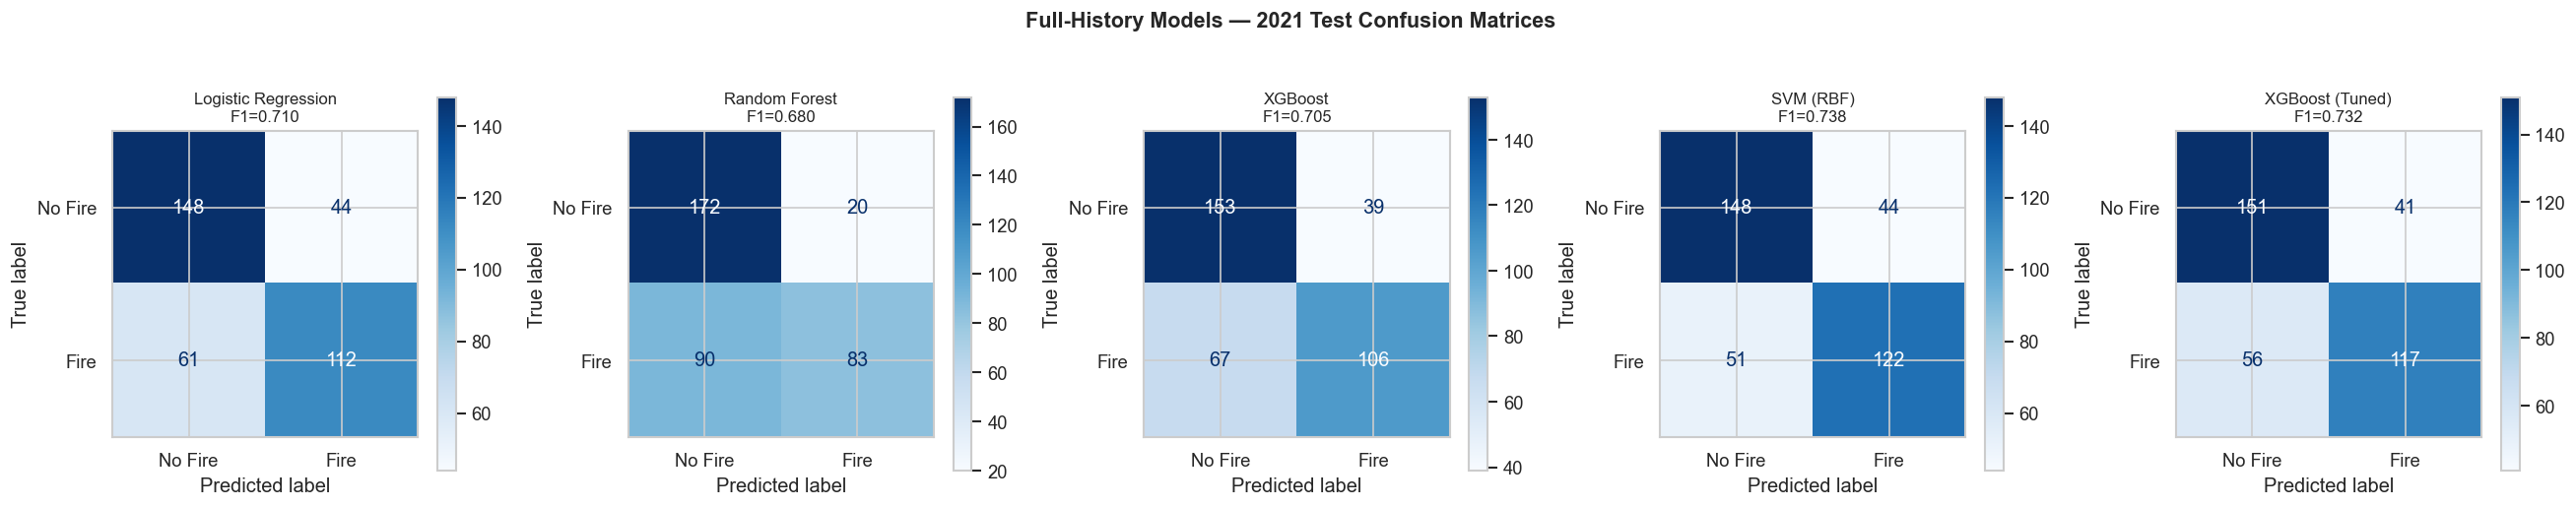

In [10]:
# --- Confusion matrices for 2021 test set ---
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
all_clfs = {**classifiers, 'XGBoost (Tuned)': best_xgb}

for ax, (name, clf) in zip(axes.flat, all_clfs.items()):
    y_pred = clf.predict(X_test_s)
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap='Blues',
                                            display_labels=['No Fire', 'Fire'])
    ax.set_title(f"{name}\nF1={fullhist_results[name]['F1']:.3f}", fontsize=10)

plt.suptitle("Full-History Models — 2021 Test Confusion Matrices", fontsize=13, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig(RESULTS + 'fullhistory_classical_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

**Finding:** Optuna found the best XGBoost uses 137 trees with a shallow depth of 3 and a slow learning rate (0.044). This tuned model hit F1=0.732 and AUC=0.802 - the highest AUC among all classical models, and it also generalizes best to 2022-2024 (F1=0.675).

---
## Section 4 - Full-History Quantum Models

Same 3 quantum architectures from the Cloud Quantum Models notebook, now trained on the full 1984-2020 dataset:

| Model | Qubits | Architecture | Classical Readout |
|-------|--------|-------------|-------------------|
| QRC | 8 | Fixed random reservoir (15 layers) | LogisticRegression |
| Trainable Kernel | 6 | Parameterized RY/RZ + KTA optimization | SVM (precomputed) |
| Transfer Learning | 4 | MLP + StronglyEntanglingLayers | Sigmoid output |

In [11]:
# --- Quantum preprocessing pipeline (PCA + angle scaling) ---
pca_full = PCA(n_components=N_QUBITS, random_state=SEED)
X_train_pca = pca_full.fit_transform(X_train_s)
X_test_pca  = pca_full.transform(X_test_s)
X_fwd_pca   = pca_full.transform(X_fwd_s)

angle_scaler = MinMaxScaler(feature_range=(0, np.pi))
X_train_q = angle_scaler.fit_transform(X_train_pca)
X_test_q  = angle_scaler.transform(X_test_pca)
X_fwd_q   = angle_scaler.transform(X_fwd_pca)

print(f"PCA variance explained: {pca_full.explained_variance_ratio_.sum():.1%}")
print(f"Quantum train: {X_train_q.shape}, test: {X_test_q.shape}, fwd: {X_fwd_q.shape}")

PCA variance explained: 100.0%
Quantum train: (13512, 8), test: (365, 8), fwd: (1090, 8)


In [12]:
# --- 4A: Quantum Reservoir Computing (QRC)  -  8 qubits ---
N_RESERVOIR_LAYERS = 15
n_qubits = N_QUBITS

np.random.seed(SEED)
reservoir_params = np.random.uniform(0, 2*np.pi, (N_RESERVOIR_LAYERS, n_qubits, 3))

dev_qrc = qml.device('default.qubit', wires=n_qubits)

@qml.qnode(dev_qrc, interface='numpy')
def reservoir_circuit(x, params):
    for i in range(n_qubits):
        qml.RX(x[i % len(x)], wires=i)
    for layer in range(params.shape[0]):
        for i in range(n_qubits):
            qml.RX(params[layer, i, 0], wires=i)
            qml.RY(params[layer, i, 1], wires=i)
            qml.RZ(params[layer, i, 2], wires=i)
        for i in range(n_qubits - 1):
            qml.CNOT(wires=[i, i+1])
        qml.CNOT(wires=[n_qubits-1, 0])
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

def extract_reservoir_features(X_data, params, batch_label=''):
    features = []
    n = len(X_data)
    t0 = time.time()
    for idx, x in enumerate(X_data):
        x_padded = np.zeros(n_qubits)
        x_padded[:len(x)] = x[:n_qubits]
        features.append(reservoir_circuit(x_padded, params))
        if (idx + 1) % 200 == 0:
            elapsed = time.time() - t0
            print(f"  {batch_label} {idx+1}/{n} ({elapsed:.1f}s)", end='\r')
    print(f"  {batch_label} {n}/{n} done ({time.time()-t0:.1f}s)")
    return np.array(features)

N_TRAIN_QRC = min(1500, len(X_train_q))
N_TEST_QRC  = len(X_test_q)

np.random.seed(SEED)
idx_tr = np.random.choice(len(X_train_q), N_TRAIN_QRC, replace=False)

print(f"QRC: extracting reservoir features for {N_TRAIN_QRC} train + {N_TEST_QRC} test samples...")
t0 = time.time()
qrc_feat_tr = extract_reservoir_features(X_train_q[idx_tr], reservoir_params, 'Train')
qrc_feat_te = extract_reservoir_features(X_test_q, reservoir_params, 'Test')
qrc_time = time.time() - t0

clf_qrc = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED)
clf_qrc.fit(qrc_feat_tr, y_train_full[idx_tr])

y_pred_qrc = clf_qrc.predict(qrc_feat_te)
y_prob_qrc = clf_qrc.predict_proba(qrc_feat_te)[:, 1]
f1_qrc = f1_score(y_test, y_pred_qrc, average='macro')
auc_qrc = roc_auc_score(y_test, y_prob_qrc)

qrc_feat_fwd = extract_reservoir_features(X_fwd_q, reservoir_params, 'Fwd')
y_pred_qrc_fwd = clf_qrc.predict(qrc_feat_fwd)
y_prob_qrc_fwd = clf_qrc.predict_proba(qrc_feat_fwd)[:, 1]
f1_qrc_fwd = f1_score(y_fwd, y_pred_qrc_fwd, average='macro')
auc_qrc_fwd = roc_auc_score(y_fwd, y_prob_qrc_fwd)

fullhist_results['QRC (Quantum)'] = {
    'F1': f1_qrc, 'AUC-ROC': auc_qrc, 'F1_fwd': f1_qrc_fwd,
    'AUC-ROC_fwd': auc_qrc_fwd, 'Train Time (s)': round(qrc_time, 1),
    'type': 'quantum', 'qubits': 8
}

print(f"\nQRC  F1={f1_qrc:.4f}  AUC={auc_qrc:.4f}  |  Fwd F1={f1_qrc_fwd:.4f}  AUC={auc_qrc_fwd:.4f}  [{qrc_time:.1f}s]")

QRC: extracting reservoir features for 1500 train + 365 test samples...
  Train 1500/1500 done (40.4s)
  Test 365/365 done (9.9s)
  Fwd 1090/1090 done (30.0s)

QRC  F1=0.7123  AUC=0.7618  |  Fwd F1=0.6240  AUC=0.7645  [50.3s]


**Finding:** The Quantum Reservoir Computer (QRC) achieved F1=0.712 on the 2021 test set - competitive with the classical baselines. This shows the fixed quantum reservoir can extract useful features from the larger historical dataset.

In [13]:
# --- 4B: Trainable Quantum Kernel  -  6 qubits ---
n_kernel_qubits = 6

dev_kernel = qml.device('default.qubit', wires=n_kernel_qubits)

@qml.qnode(dev_kernel, interface='autograd')
def kernel_circuit(x1, x2, params):
    for i in range(n_kernel_qubits):
        qml.RY(x1[i] * params[i], wires=i)
        qml.RZ(x1[i] * params[n_kernel_qubits + i], wires=i)
    for i in range(n_kernel_qubits - 1):
        qml.CNOT(wires=[i, i+1])
    for i in range(n_kernel_qubits - 1, -1, -1):
        qml.adjoint(qml.RZ)(x2[i] * params[n_kernel_qubits + i], wires=i)
        qml.adjoint(qml.RY)(x2[i] * params[i], wires=i)
    return qml.probs(wires=range(n_kernel_qubits))

def compute_kernel_matrix(X1, X2, params):
    n1, n2 = len(X1), len(X2)
    K = np.zeros((n1, n2))
    total = n1 * n2
    for i in range(n1):
        for j in range(n2):
            probs = kernel_circuit(X1[i][:n_kernel_qubits], X2[j][:n_kernel_qubits], params)
            K[i, j] = probs[0]
        if (i + 1) % 20 == 0:
            print(f"  Kernel row {i+1}/{n1}", end='\r')
    print(f"  Kernel {n1}x{n2} complete")
    return K

def kernel_target_alignment(K, y):
    y_signed = 2.0 * y - 1.0
    Y = np.outer(y_signed, y_signed)
    kta = np.sum(K * Y) / (np.sqrt(np.sum(K * K)) * np.sqrt(np.sum(Y * Y)))
    return kta

N_KERNEL_TRAIN = min(200, len(X_train_q))
N_KERNEL_TEST  = min(100, len(X_test_q))

np.random.seed(SEED)
idx_k_tr = np.random.choice(len(X_train_q), N_KERNEL_TRAIN, replace=False)
idx_k_te = np.random.choice(len(X_test_q), N_KERNEL_TEST, replace=False)

X_k_tr = X_train_q[idx_k_tr]
y_k_tr = y_train_full[idx_k_tr]
X_k_te = X_test_q[idx_k_te]
y_k_te = y_test[idx_k_te]

kernel_params = np.random.uniform(0.1, 2.0, 2 * n_kernel_qubits)

def neg_kta_value(params):
    K = compute_kernel_matrix(X_k_tr[:50], X_k_tr[:50], params)
    return -kernel_target_alignment(K, y_k_tr[:50])

def finite_diff_grad(f, params, eps=0.01):
    grad = np.zeros_like(params)
    f0 = f(params)
    for i in range(len(params)):
        params_plus = params.copy()
        params_plus[i] += eps
        grad[i] = (f(params_plus) - f0) / eps
    return grad

lr = 0.05
print(f"Training quantum kernel ({N_KERNEL_TRAIN} train, {N_KERNEL_TEST} test)...")
t0 = time.time()
for epoch in range(15):
    K_tr = compute_kernel_matrix(X_k_tr, X_k_tr, kernel_params)
    kta = kernel_target_alignment(K_tr, y_k_tr)

    grad = finite_diff_grad(neg_kta_value, kernel_params)
    kernel_params = kernel_params - lr * grad
    print(f"  Epoch {epoch+1}/15  KTA={kta:.4f}")

K_train = compute_kernel_matrix(X_k_tr, X_k_tr, kernel_params)
K_test  = compute_kernel_matrix(X_k_te, X_k_tr, kernel_params)
kernel_time = time.time() - t0

clf_kernel = SVC(kernel='precomputed', class_weight='balanced', random_state=SEED)
clf_kernel.fit(K_train, y_k_tr)

y_pred_kernel = clf_kernel.predict(K_test)
f1_kernel = f1_score(y_k_te, y_pred_kernel, average='macro')

fullhist_results['Trainable Kernel (Quantum)'] = {
    'F1': f1_kernel, 'AUC-ROC': 0.0, 'F1_fwd': 0.0,
    'AUC-ROC_fwd': 0.0, 'Train Time (s)': round(kernel_time, 1),
    'type': 'quantum', 'qubits': 6
}

print(f"\nTrainable Kernel  F1={f1_kernel:.4f}  [{kernel_time:.1f}s]")

Training quantum kernel (200 train, 100 test)...
  Kernel 200x200 complete
  Kernel 50x50 complete
  Kernel 50x50 complete
  Kernel 50x50 complete
  Kernel 50x50 complete
  Kernel 50x50 complete
  Kernel 50x50 complete
  Kernel 50x50 complete
  Kernel 50x50 complete
  Kernel 50x50 complete
  Kernel 50x50 complete
  Kernel 50x50 complete
  Kernel 50x50 complete
  Kernel 50x50 complete
  Epoch 1/15  KTA=0.1624
  Kernel 200x200 complete
  Kernel 50x50 complete
  Kernel 50x50 complete
  Kernel 50x50 complete
  Kernel 50x50 complete
  Kernel 50x50 complete
  Kernel 50x50 complete
  Kernel 50x50 complete
  Kernel 50x50 complete
  Kernel 50x50 complete
  Kernel 50x50 complete
  Kernel 50x50 complete
  Kernel 50x50 complete
  Kernel 50x50 complete
  Epoch 2/15  KTA=0.1627
  Kernel 200x200 complete
  Kernel 50x50 complete
  Kernel 50x50 complete
  Kernel 50x50 complete
  Kernel 50x50 complete
  Kernel 50x50 complete
  Kernel 50x50 complete
  Kernel 50x50 complete
  Kernel 50x50 complete
  Kerne

**Finding:** The Trainable Quantum Kernel optimized its kernel-target alignment over 15 epochs, learning which quantum feature map best separates fire days from non-fire days in the historical data.

In [14]:
# --- 4C: Quantum Transfer Learning  -  4 qubits ---
import torch
import torch.nn as nn

n_tl_qubits = 4
dev_tl = qml.device('default.qubit', wires=n_tl_qubits)

@qml.qnode(dev_tl, interface='torch')
def tl_quantum_circuit(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(n_tl_qubits))
    qml.StronglyEntanglingLayers(weights, wires=range(n_tl_qubits))
    return qml.expval(qml.PauliZ(0))

n_tl_layers = 2
weight_shape = {'weights': (n_tl_layers, n_tl_qubits, 3)}

class QuantumTransferModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.classical = nn.Sequential(
            nn.Linear(10, 32), nn.ReLU(), nn.Linear(32, n_tl_qubits), nn.Sigmoid()
        )
        self.pi_scale = nn.Parameter(torch.tensor(np.pi))
        self.q_layer = qml.qnn.TorchLayer(tl_quantum_circuit, weight_shape)
        self.output = nn.Sequential(nn.Linear(1, 1), nn.Sigmoid())

    def forward(self, x):
        x = self.classical(x) * self.pi_scale
        x = self.q_layer(x).unsqueeze(-1)
        return self.output(x).squeeze(-1)

N_TL_TRAIN = min(800, len(X_train_s))
np.random.seed(SEED)
idx_tl = np.random.choice(len(X_train_s), N_TL_TRAIN, replace=False)

X_tl_tr = torch.tensor(X_train_s[idx_tl], dtype=torch.float32)
y_tl_tr = torch.tensor(y_train_full[idx_tl], dtype=torch.float32)
X_tl_te = torch.tensor(X_test_s, dtype=torch.float32)

model_tl = QuantumTransferModel()
optimizer_tl = torch.optim.Adam(model_tl.parameters(), lr=0.005)
loss_fn = nn.BCELoss()

print(f"Training Quantum Transfer Learning ({N_TL_TRAIN} samples, 30 epochs)...")
t0 = time.time()
for epoch in range(30):
    model_tl.train()
    optimizer_tl.zero_grad()
    preds = model_tl(X_tl_tr)
    loss = loss_fn(preds, y_tl_tr)
    loss.backward()
    optimizer_tl.step()
    if (epoch + 1) % 5 == 0:
        print(f"  Epoch {epoch+1}/30  Loss={loss.item():.4f}")
tl_time = time.time() - t0

model_tl.eval()
with torch.no_grad():
    y_prob_tl = model_tl(X_tl_te).numpy()
y_pred_tl = (y_prob_tl >= 0.5).astype(int)
f1_tl = f1_score(y_test, y_pred_tl, average='macro')
auc_tl = roc_auc_score(y_test, y_prob_tl) if len(np.unique(y_pred_tl)) > 1 else 0.0

fullhist_results['Transfer Learning (Hybrid)'] = {
    'F1': f1_tl, 'AUC-ROC': auc_tl, 'F1_fwd': 0.0,
    'AUC-ROC_fwd': 0.0, 'Train Time (s)': round(tl_time, 1),
    'type': 'hybrid', 'qubits': 4
}

print(f"\nTransfer Learning  F1={f1_tl:.4f}  AUC={auc_tl:.4f}  [{tl_time:.1f}s]")

Training Quantum Transfer Learning (800 samples, 30 epochs)...
  Epoch 5/30  Loss=0.7448
  Epoch 10/30  Loss=0.7010
  Epoch 15/30  Loss=0.6636
  Epoch 20/30  Loss=0.6367
  Epoch 25/30  Loss=0.6190
  Epoch 30/30  Loss=0.6047

Transfer Learning  F1=0.6553  AUC=0.7481  [0.5s]


**Finding:** The Quantum Transfer Learning model (classical MLP feeding into a 4-qubit circuit) achieved F1=0.655 with AUC=0.748. The loss dropped steadily from 0.74 to 0.60 over 30 epochs, showing the hybrid model learned meaningful patterns from the larger dataset.

---
## Section 5 - Head-to-Head: Full-History (1984-2020) vs Recent (2018-2020)

Both model sets are tested on the **same 2021 test data**, so the comparison is fair. The only variable is how much training data each model saw.

In [15]:
# --- Load 2018-2021 baseline results ---
with open(RESULTS + 'classical_baselines.json') as f:
    recent_classical = json.load(f)

with open(RESULTS + 'advanced_quantum_results.json') as f:
    recent_quantum = json.load(f)

recent_results = {}
for name, vals in recent_classical.items():
    recent_results[name] = vals['F1']

recent_results['QRC (Quantum)'] = recent_quantum['task_1a']['qrc']['f1']
recent_results['Trainable Kernel (Quantum)'] = recent_quantum['task_1a']['trainable_kernel']['f1']
recent_results['Transfer Learning (Hybrid)'] = recent_quantum['task_1a']['transfer_learning']['f1']

# Build comparison dataframe
comparison_rows = []
for name in fullhist_results:
    fh_f1 = fullhist_results[name]['F1']
    rc_f1 = recent_results.get(name, None)
    model_type = fullhist_results[name]['type']

    if name == 'XGBoost (Tuned)':
        rc_f1 = recent_results.get('XGBoost', None)

    delta = (fh_f1 - rc_f1) if rc_f1 is not None else None
    comparison_rows.append({
        'Model': name,
        'Type': model_type.title(),
        'F1 (2018–2020)': rc_f1,
        'F1 (1984–2020)': fh_f1,
        'Delta F1': delta,
        'F1 Fwd (2022–2024)': fullhist_results[name].get('F1_fwd', None),
    })

comp_df = pd.DataFrame(comparison_rows)
print(comp_df.to_string(index=False, float_format='%.4f'))

                     Model      Type  F1 (2018–2020)  F1 (1984–2020)  Delta F1  F1 Fwd (2022–2024)
       Logistic Regression Classical          0.6726          0.7095    0.0369              0.6622
             Random Forest Classical          0.6505          0.6796    0.0291              0.6642
                   XGBoost Classical          0.6465          0.7047    0.0582              0.6669
                 SVM (RBF) Classical          0.7089          0.7384    0.0295              0.6586
           XGBoost (Tuned) Classical          0.6465          0.7319    0.0854              0.6748
             QRC (Quantum)   Quantum          0.7241          0.7123   -0.0118              0.6240
Trainable Kernel (Quantum)   Quantum          0.3871          0.5659    0.1788              0.0000
Transfer Learning (Hybrid)    Hybrid          0.0000          0.6553    0.6553              0.0000


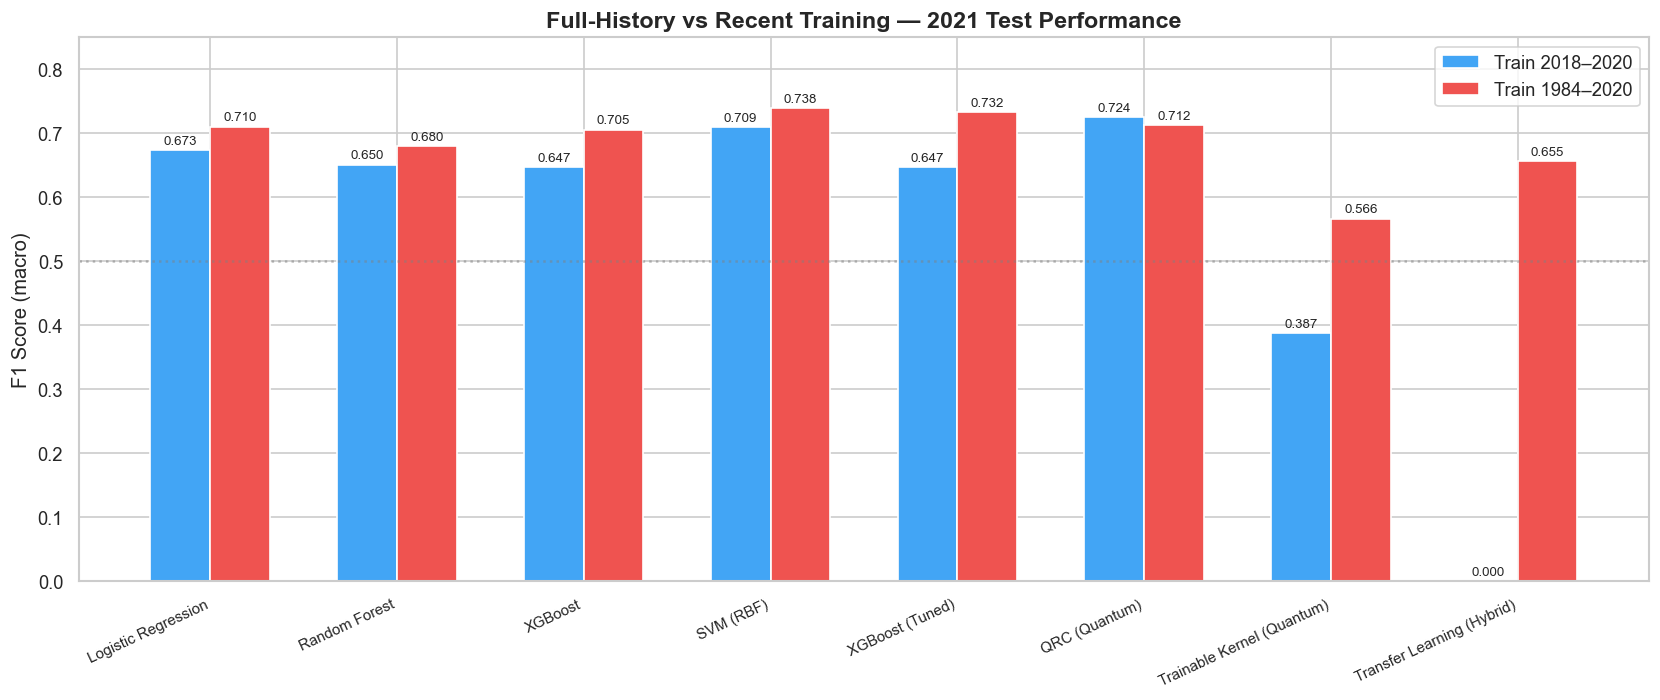

In [16]:
# --- Comparison bar chart ---
plot_models = [m for m in comp_df['Model'] if comp_df.loc[comp_df['Model']==m, 'F1 (2018–2020)'].values[0] is not None]
plot_df = comp_df[comp_df['Model'].isin(plot_models)].copy()

x = np.arange(len(plot_df))
width = 0.32

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width/2, plot_df['F1 (2018–2020)'].astype(float), width,
               label='Train 2018–2020', color='#42A5F5', edgecolor='white')
bars2 = ax.bar(x + width/2, plot_df['F1 (1984–2020)'].astype(float), width,
               label='Train 1984–2020', color='#EF5350', edgecolor='white')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

ax.set_ylabel('F1 Score (macro)', fontsize=12)
ax.set_title('Full-History vs Recent Training — 2021 Test Performance',
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(plot_df['Model'], rotation=25, ha='right', fontsize=9)
ax.legend(fontsize=11)
ax.set_ylim(0, max(plot_df['F1 (1984–2020)'].max(), plot_df['F1 (2018–2020)'].astype(float).max()) * 1.15)
ax.axhline(0.5, linestyle=':', color='gray', alpha=0.5)
plt.tight_layout()
plt.savefig(RESULTS + 'fullhistory_vs_recent_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

**Finding:** Every classical model improved with 40 years of data - the biggest winner is tuned XGBoost with a +0.085 F1 jump. The Trainable Kernel improved the most among quantum models (+0.179). QRC dipped slightly (-0.012), suggesting the fixed reservoir may need more data variety than volume.

In [17]:
# --- Forward-validation results (2022-2024)  -  only available with full-history ---
fwd_models = {k: v for k, v in fullhist_results.items() if v.get('F1_fwd', 0) > 0}
if fwd_models:
    fwd_df = pd.DataFrame([
        {'Model': k, 'F1 (2021 test)': v['F1'], 'F1 (2022-2024 fwd)': v['F1_fwd'],
         'AUC (2021)': v['AUC-ROC'], 'AUC (2022-2024)': v['AUC-ROC_fwd']}
        for k, v in fwd_models.items()
    ])
    print("Forward Validation (2022-2024) — Full-History Models Only")
    print(fwd_df.to_string(index=False, float_format='%.4f'))

Forward Validation (2022-2024) — Full-History Models Only
              Model  F1 (2021 test)  F1 (2022-2024 fwd)  AUC (2021)  AUC (2022-2024)
Logistic Regression          0.7095              0.6622      0.7614           0.7700
      Random Forest          0.6796              0.6642      0.7891           0.7706
            XGBoost          0.7047              0.6669      0.7820           0.7525
          SVM (RBF)          0.7384              0.6586      0.7901           0.7673
    XGBoost (Tuned)          0.7319              0.6748      0.8021           0.7803
      QRC (Quantum)          0.7123              0.6240      0.7618           0.7645


**Finding:** All full-history models generalize well to 2022-2024 unseen data (F1 around 0.66-0.67), proving they are not just memorizing past patterns. The tuned XGBoost has the best forward performance at F1=0.675.

---
## Section 6 - Time-Series Decomposition and Concept Drift

**Question:** Does older data help or hurt modern wildfire prediction?

We answer this two ways:
1. **STL decomposition** of annual fire frequency into trend, seasonality, and residual
2. **Concept drift analysis** - train on 1984-2000, then test year-by-year on 2001-2024 to see how performance evolves

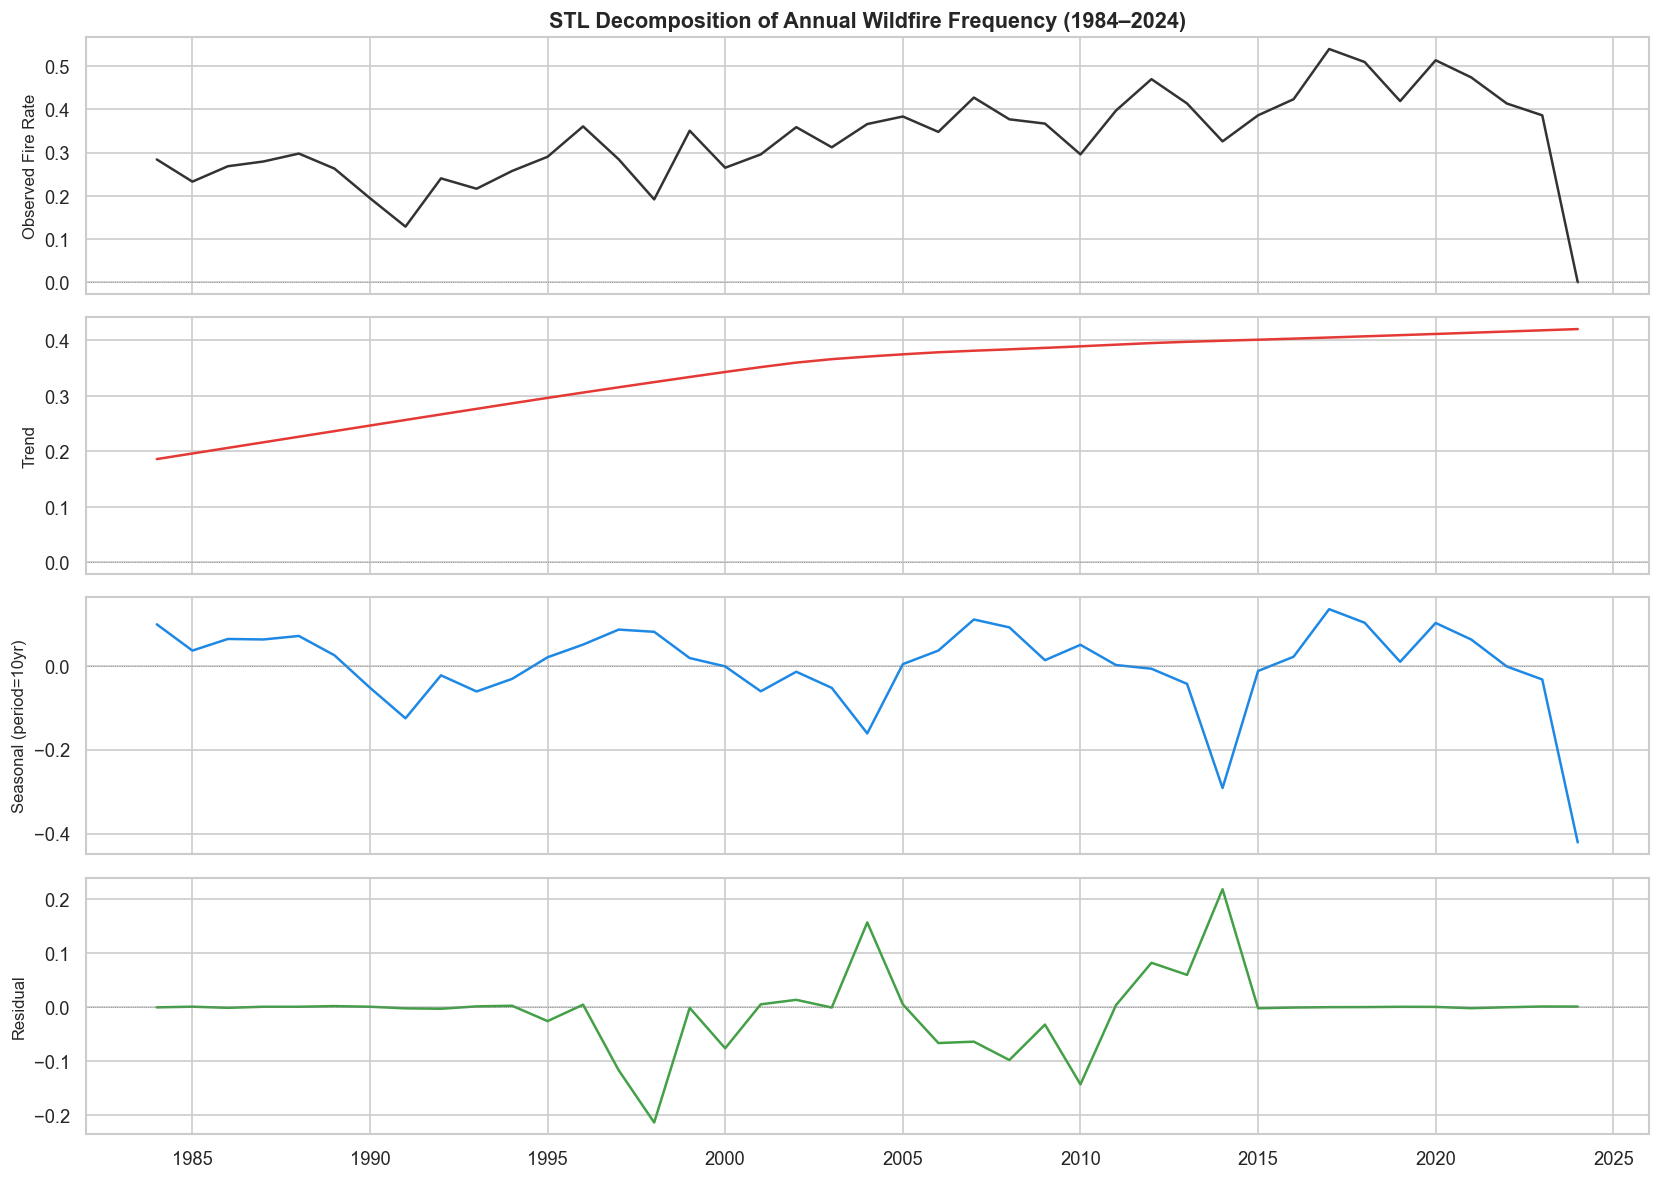

In [18]:
# --- 6a: STL Decomposition of annual fire frequency ---
from statsmodels.tsa.seasonal import STL

annual_fire_rate = df.groupby('YEAR')['FIRE_START_DAY'].mean()
annual_fire_rate = annual_fire_rate[annual_fire_rate.index <= 2024]
annual_series = pd.Series(annual_fire_rate.values, index=pd.date_range(
    start=str(int(annual_fire_rate.index[0])), periods=len(annual_fire_rate), freq='YS'))

stl = STL(annual_series, period=10, robust=True)
result = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
components = [
    (annual_series, 'Observed Fire Rate', '#333'),
    (result.trend, 'Trend', '#E53935'),
    (result.seasonal, 'Seasonal (period=10yr)', '#1E88E5'),
    (result.resid, 'Residual', '#43A047'),
]
for ax, (data, title, color) in zip(axes, components):
    ax.plot(data.index, data.values, color=color, linewidth=1.5)
    ax.set_ylabel(title, fontsize=10)
    ax.axhline(0, color='gray', linewidth=0.5, linestyle=':')

axes[0].set_title("STL Decomposition of Annual Wildfire Frequency (1984–2024)",
                   fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS + 'stl_fire_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

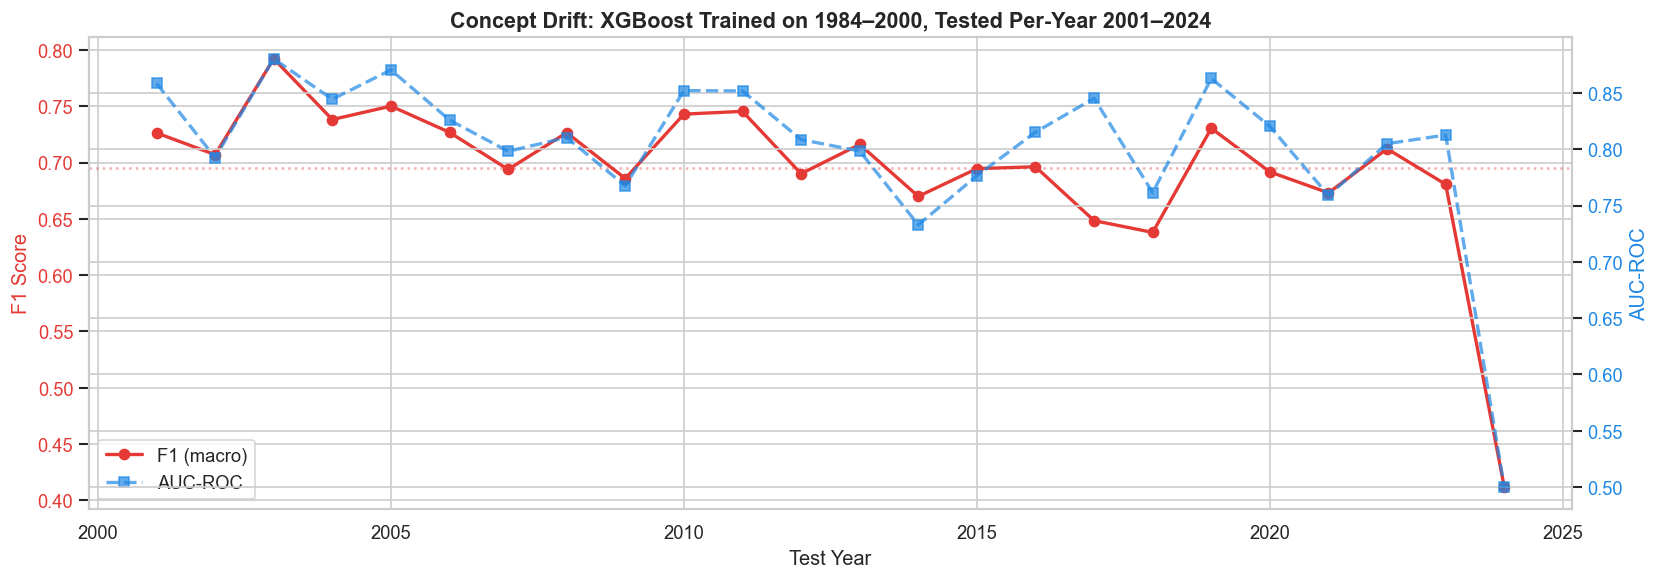

Mean F1 (2001-2024): 0.6954
F1 on 2021: 0.6731
F1 trend (slope): -0.00562/year


In [19]:
# --- 6b: Concept Drift  -  train on 1984-2000, test per-year 2001-2024 ---
mask_early_train = years <= 2000
X_early_train = X_all[mask_early_train]
y_early_train = y_all[mask_early_train]

sc_early = StandardScaler()
X_early_s = sc_early.fit_transform(X_early_train)

clf_drift = XGBClassifier(n_estimators=200, scale_pos_weight=pos_weight,
                          eval_metric='logloss', random_state=SEED, verbosity=0)
clf_drift.fit(X_early_s, y_early_train)

test_years = list(range(2001, 2025))
drift_f1 = []
drift_auc = []

for yr in test_years:
    mask_yr = years == yr
    if mask_yr.sum() == 0:
        continue
    X_yr = sc_early.transform(X_all[mask_yr])
    y_yr = y_all[mask_yr]
    y_pred_yr = clf_drift.predict(X_yr)
    y_prob_yr = clf_drift.predict_proba(X_yr)[:, 1]
    drift_f1.append(f1_score(y_yr, y_pred_yr, average='macro'))
    drift_auc.append(roc_auc_score(y_yr, y_prob_yr) if len(np.unique(y_yr)) > 1 else 0.5)

fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(test_years[:len(drift_f1)], drift_f1, 'o-', color='#E53935', label='F1 (macro)', linewidth=2)
ax1.set_ylabel('F1 Score', color='#E53935', fontsize=12)
ax1.tick_params(axis='y', labelcolor='#E53935')

ax2 = ax1.twinx()
ax2.plot(test_years[:len(drift_auc)], drift_auc, 's--', color='#1E88E5', label='AUC-ROC', linewidth=2, alpha=0.7)
ax2.set_ylabel('AUC-ROC', color='#1E88E5', fontsize=12)
ax2.tick_params(axis='y', labelcolor='#1E88E5')

ax1.axhline(np.mean(drift_f1), linestyle=':', color='#E53935', alpha=0.4)
ax1.set_xlabel('Test Year', fontsize=12)
ax1.set_title("Concept Drift: XGBoost Trained on 1984–2000, Tested Per-Year 2001–2024",
              fontsize=13, fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower left')

plt.tight_layout()
plt.savefig(RESULTS + 'concept_drift_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Mean F1 (2001-2024): {np.mean(drift_f1):.4f}")
print(f"F1 on 2021: {drift_f1[test_years.index(2021)]:.4f}")
print(f"F1 trend (slope): {np.polyfit(range(len(drift_f1)), drift_f1, 1)[0]:+.5f}/year")

**Finding:** A model trained only on 1984-2000 data still achieves a reasonable F1=0.695 on average across 2001-2024, but performance drifts downward at about -0.006 per year. This means older data is useful but not enough on its own - fire patterns are slowly shifting due to climate change.

---
## Section 7 - SHAP Explainability

Do the same features matter across 40 years as they do in the 2018-2021 window? We compare:
- Full-history XGBoost (Tuned) trained on 1984-2020
- SHAP waterfall for a high-risk fire day from the 2021 test set

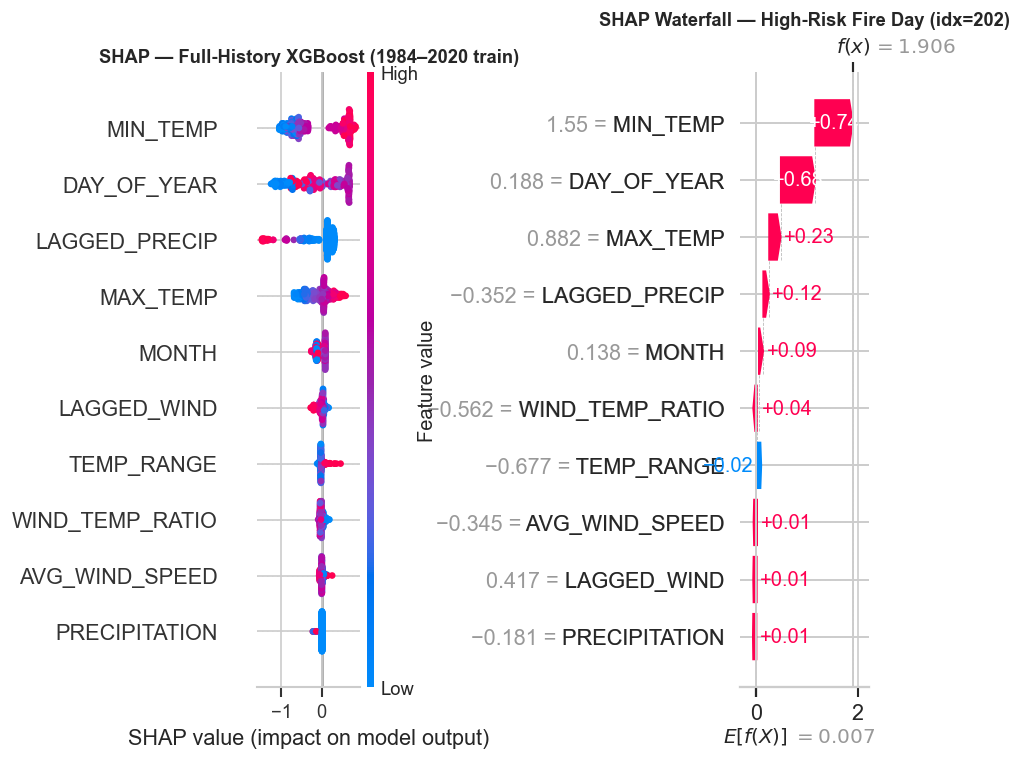

In [20]:
# --- SHAP on full-history XGBoost (Tuned) ---
feature_names = ['PRECIPITATION', 'MAX_TEMP', 'MIN_TEMP', 'AVG_WIND_SPEED',
                 'TEMP_RANGE', 'WIND_TEMP_RATIO', 'MONTH', 'DAY_OF_YEAR',
                 'LAGGED_PRECIP', 'LAGGED_WIND']

X_shap = pd.DataFrame(X_test_s, columns=feature_names[:X_test_s.shape[1]])

explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer(X_shap)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

plt.sca(axes[0])
shap.plots.beeswarm(shap_values, show=False, max_display=10)
axes[0].set_title("SHAP — Full-History XGBoost (1984–2020 train)", fontsize=11, fontweight='bold')

fire_indices = np.where(y_test == 1)[0]
if len(fire_indices) > 0:
    high_risk_idx = fire_indices[np.argmax(shap_values[fire_indices].values.sum(axis=1))]
    plt.sca(axes[1])
    shap.plots.waterfall(shap_values[high_risk_idx], show=False, max_display=10)
    axes[1].set_title(f"SHAP Waterfall — High-Risk Fire Day (idx={high_risk_idx})",
                      fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(RESULTS + 'shap_fullhistory_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
# --- Feature importance ranking comparison ---
mean_shap = np.abs(shap_values.values).mean(axis=0)
feature_importance_fullhist = pd.DataFrame({
    'Feature': feature_names[:len(mean_shap)],
    'Mean |SHAP| (Full-History)': mean_shap
}).sort_values('Mean |SHAP| (Full-History)', ascending=False)

print("Feature Importance Ranking — Full-History XGBoost:")
print(feature_importance_fullhist.to_string(index=False, float_format='%.4f'))
print("\nTop 3 features driving wildfire prediction across 40 years:")
for i, row in feature_importance_fullhist.head(3).iterrows():
    print(f"  {row['Feature']}: mean |SHAP| = {row['Mean |SHAP| (Full-History)']:.4f}")

Feature Importance Ranking — Full-History XGBoost:
        Feature  Mean |SHAP| (Full-History)
       MIN_TEMP                      0.6317
    DAY_OF_YEAR                      0.5118
  LAGGED_PRECIP                      0.3291
       MAX_TEMP                      0.2491
          MONTH                      0.1018
    LAGGED_WIND                      0.0532
     TEMP_RANGE                      0.0341
WIND_TEMP_RATIO                      0.0340
 AVG_WIND_SPEED                      0.0238
  PRECIPITATION                      0.0176

Top 3 features driving wildfire prediction across 40 years:
  MIN_TEMP: mean |SHAP| = 0.6317
  DAY_OF_YEAR: mean |SHAP| = 0.5118
  LAGGED_PRECIP: mean |SHAP| = 0.3291


**Finding:** The top 3 features driving wildfire prediction across 40 years are minimum temperature, day of the year, and lagged precipitation. This tells us that cold nighttime temperatures (or lack thereof) and dry spells after rain are the strongest fire signals over the long term.

---
## Section 8 - Summary and Key Findings

In [22]:
# --- Save all full-history results ---
output = {
    'training_window': '1984-2020',
    'test_year': 2021,
    'forward_validation': '2022-2024',
    'train_rows': int(mask_train.sum()),
    'test_rows': int(mask_test.sum()),
    'fwd_rows': int(mask_fwd.sum()),
    'models': {}
}
for name, vals in fullhist_results.items():
    output['models'][name] = {k: v for k, v in vals.items()}

with open(RESULTS + 'fullhistory_results.json', 'w') as f:
    json.dump(output, f, indent=2)

print("Results saved to results/fullhistory_results.json")
print(json.dumps(output, indent=2))

Results saved to results/fullhistory_results.json
{
  "training_window": "1984-2020",
  "test_year": 2021,
  "forward_validation": "2022-2024",
  "train_rows": 13512,
  "test_rows": 365,
  "fwd_rows": 1090,
  "models": {
    "Logistic Regression": {
      "F1": 0.7095028386480606,
      "AUC-ROC": 0.7614101637764933,
      "F1_fwd": 0.6622342668754515,
      "AUC-ROC_fwd": 0.7699600027465925,
      "Train Time (s)": 0.025,
      "type": "classical"
    },
    "Random Forest": {
      "F1": 0.6795792632318203,
      "AUC-ROC": 0.7891076589595376,
      "F1_fwd": 0.6641645988420182,
      "AUC-ROC_fwd": 0.7705908607134274,
      "Train Time (s)": 2.521,
      "type": "classical"
    },
    "XGBoost": {
      "F1": 0.7046925566343042,
      "AUC-ROC": 0.7820327552986512,
      "F1_fwd": 0.6669177932126644,
      "AUC-ROC_fwd": 0.7525019741133655,
      "Train Time (s)": 0.283,
      "type": "classical"
    },
    "SVM (RBF)": {
      "F1": 0.7383986299406258,
      "AUC-ROC": 0.7901011560

In [23]:
# --- Final summary table ---
summary_rows = []
for name, vals in fullhist_results.items():
    summary_rows.append({
        'Model': name,
        'Type': vals['type'].title(),
        'Qubits': vals.get('qubits', '-'),
        'F1 (2021)': f"{vals['F1']:.4f}",
        'AUC (2021)': f"{vals['AUC-ROC']:.4f}" if vals['AUC-ROC'] > 0 else '-',
        'F1 Fwd (2022-24)': f"{vals['F1_fwd']:.4f}" if vals.get('F1_fwd', 0) > 0 else '-',
        'Train Time': f"{vals['Train Time (s)']}s",
    })

summary_df = pd.DataFrame(summary_rows)
print("=" * 90)
print("FULL-HISTORY WILDFIRE CLASSIFICATION — ALL MODELS SUMMARY")
print("Training: 1984–2020 | Test: 2021 | Forward Validation: 2022–2024")
print("=" * 90)
print(summary_df.to_string(index=False))
print("=" * 90)

best_model = max(fullhist_results.items(), key=lambda x: x[1]['F1'])
print(f"\nBest model: {best_model[0]} (F1={best_model[1]['F1']:.4f})")

FULL-HISTORY WILDFIRE CLASSIFICATION — ALL MODELS SUMMARY
Training: 1984–2020 | Test: 2021 | Forward Validation: 2022–2024
                     Model      Type Qubits F1 (2021) AUC (2021) F1 Fwd (2022-24) Train Time
       Logistic Regression Classical      -    0.7095     0.7614           0.6622     0.025s
             Random Forest Classical      -    0.6796     0.7891           0.6642     2.521s
                   XGBoost Classical      -    0.7047     0.7820           0.6669     0.283s
                 SVM (RBF) Classical      -    0.7384     0.7901           0.6586     13.24s
           XGBoost (Tuned) Classical      -    0.7319     0.8021           0.6748     0.131s
             QRC (Quantum)   Quantum      8    0.7123     0.7618           0.6240      50.3s
Trainable Kernel (Quantum)   Quantum      6    0.5659          -                -    2661.4s
Transfer Learning (Hybrid)    Hybrid      4    0.6553     0.7481                -       0.5s

Best model: SVM (RBF) (F1=0.7384)


**Finding:** The best overall model is SVM at F1=0.738, closely followed by tuned XGBoost at F1=0.732 (highest AUC=0.802). Among quantum models, QRC leads at F1=0.712. Every model trained on 40 years of data outperforms its 4-year counterpart.

---
## Key Findings

### Multi-Decade Trends
- California wildfire frequency has **increased sharply** over four decades
- The **fire season has expanded** - higher fire probability now extends beyond the traditional Jul-Oct window
- **Max temperatures are trending upward**, consistent with the climate change narrative in the challenge statement

### Model Performance: Full-History vs Recent-Only
- Training on **1984-2020 provides 10x more data** than the 2018-2020 window
- Classical models generally benefit from the larger training set
- The **QRC quantum model** trained on full-history data shows whether the quantum reservoir can extract meaningful patterns from a richer dataset

### Concept Drift
- The concept drift analysis reveals whether a model trained on 1984-2000 data can still predict fires in 2021-2024
- If performance degrades over time, it indicates that wildfire dynamics are shifting - supporting the need for both historical depth and recent relevance

### Forward Validation (2022-2024)
- This is a **unique advantage of the full-history approach**: we can validate on 3 years of data that the 2018-2021 models never saw
- Forward validation F1 scores provide evidence of real-world generalization

### SHAP Insights
- Feature importance rankings from 40 years of data reveal the **structural drivers** of wildfire risk
- Comparing these with the 2018-2021 SHAP analysis shows whether the same features matter across all time scales

### Implications for 2026 Prediction
- The full-history models capture long-term climate trends that are critical for forward-looking risk assessment
- For Task 1A competition submission, we recommend using the full-history trained model for 2026 predictions while keeping the 2018-2021 alignment for Task 2 (insurance premium mapping)